In [48]:
import pandas as pd
import numpy as np
import os
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
import scipy as sp

In [49]:
path = "../dataset/pecan-street-electricity-data"

files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(".csv")]

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49443400 entries, 0 to 49443399
Data columns (total 3 columns):
 #   Column       Dtype  
---  ------       -----  
 0   localminute  object 
 1   dataid       int64  
 2   use          float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ GB


In [51]:
df.describe()

,dataid,use
count,4.944340e+07,4.944340e+07
mean,4.308854e+03,9.588876e-01
std,2.911907e+03,1.347736e+00
min,2.600000e+01,-3.194300e+01
25%,1.801000e+03,3.040000e-01
50%,3.719000e+03,5.470000e-01
75%,6.941000e+03,1.004000e+00
max,9.983000e+03,3.194300e+01


In [52]:
df.head()

,localminute,dataid,use
0,2016-01-01 00:00:00-06,8046,0.887
1,2016-01-01 00:00:00-06,9983,1.181
2,2016-01-01 00:00:00-06,8059,0.130
3,2016-01-01 00:00:00-06,9555,1.299
4,2016-01-01 00:00:00-06,8079,2.719


In [53]:
# df_without_timestamp = df.drop(columns=["localminute"])
# scatter_matrix(df_without_timestamp, figsize=(7,7))
# pyplot.show()   

In [54]:
# pyplot.hist(df["use"], bins='auto')
# pyplot.title('Histograma')
# pyplot.ylabel('Frequencia')
# pyplot.xlabel("Uso")
# pyplot.show()

In [55]:
amostra = df.sample(n=1000, random_state=42)

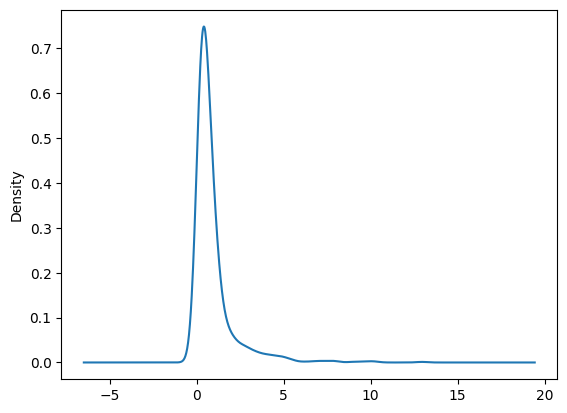

In [ ]:
amostra['use'].plot(kind='kde')
# amostra.plot.scatter(x='use', y='dataid', colormap='viridis')
pyplot.show()


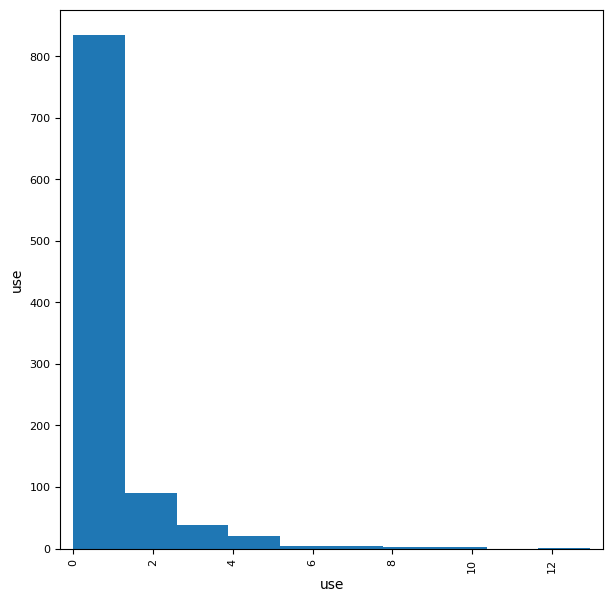

In [57]:
scatter_matrix(amostra.drop(columns=["localminute", "dataid"]), figsize=(7,7))
pyplot.show()

## Agrupando por data

In [58]:
#df_aggregated = df.copy()
df_aggregated = df.sample(1000)

### Garante que o timestamp é no formato datetime e define o index

In [59]:
aggregate_freq = "1000min"

In [60]:
df_aggregated = (
    df_aggregated
    .assign(localminute=pd.to_datetime(df['localminute'], utc=True))
    .groupby([
        'dataid',
        pd.Grouper(key='localminute', freq=aggregate_freq)
    ])
    .mean()
    .dropna()
)

In [61]:
df_aggregated.head()

use
dataid localminute                     
26     2016-02-04 00:40:00+00:00  0.397
       2016-02-13 18:00:00+00:00  4.478
59     2016-01-17 16:00:00+00:00  4.763
       2016-02-22 02:00:00+00:00  0.441
       2016-02-25 13:20:00+00:00  1.955

In [62]:
df_aggregated.describe()

,use
count,993.000000
mean,0.868199
std,1.165303
min,0.000000
25%,0.289000
50%,0.508000
75%,0.946000
max,17.647000


In [63]:
df_aggregated.loc[77]['use'].mean()

np.float64(0.7394999999999999)

In [64]:
df_aggregated.index

MultiIndex([(  26, '2016-02-04 00:40:00+00:00'),
            (  26, '2016-02-13 18:00:00+00:00'),
            (  59, '2016-01-17 16:00:00+00:00'),
            (  59, '2016-02-22 02:00:00+00:00'),
            (  59, '2016-02-25 13:20:00+00:00'),
            (  59, '2016-03-31 23:20:00+00:00'),
            (  77, '2016-02-24 20:40:00+00:00'),
            (  77, '2016-04-23 04:40:00+00:00'),
            (  86, '2016-03-31 23:20:00+00:00'),
            (  93, '2016-01-04 11:20:00+00:00'),
            ...
            (9971, '2016-01-03 18:40:00+00:00'),
            (9971, '2016-01-07 06:00:00+00:00'),
            (9971, '2016-01-10 17:20:00+00:00'),
            (9971, '2016-02-18 14:40:00+00:00'),
            (9971, '2016-02-20 00:00:00+00:00'),
            (9982, '2016-01-15 14:00:00+00:00'),
            (9982, '2016-01-21 20:00:00+00:00'),
            (9982, '2016-01-29 11:20:00+00:00'),
            (9982, '2016-02-16 12:40:00+00:00'),
            (9982, '2016-02-26 06:00:00+00:00')],
   

In [65]:
df_aggregated['use_norm'] = (
    df_aggregated['use'] /
    df_aggregated.groupby(level=0)['use'].transform('mean')
)

In [66]:
df_aggregated.head()

use  use_norm
dataid localminute                               
26     2016-02-04 00:40:00+00:00  0.397  0.162872
       2016-02-13 18:00:00+00:00  4.478  1.837128
59     2016-01-17 16:00:00+00:00  4.763  2.534522
       2016-02-22 02:00:00+00:00  0.441  0.234668
       2016-02-25 13:20:00+00:00  1.955  1.040309

In [67]:
df_aggregated.loc[77]

,use,use_norm
localminute,,
2016-02-24 20:40:00+00:00,1.037,1.402299
2016-04-23 04:40:00+00:00,0.442,0.597701


In [68]:
df_mean = df.groupby("dataid")["use"].mean().reset_index()